In [1]:
!git clone https://github.com/hoangquan1503/Walmart_sales_forecasting.git

Cloning into 'Walmart_sales_forecasting'...
remote: Enumerating objects: 262, done.
remote: Counting objects: 100% (262/262), done.
remote: Compressing objects: 100% (183/183), done.
remote: Total 262 (delta 112), reused 224 (delta 74), pack-reused 0 (from 0)
Receiving objects: 100% (262/262), 4.36 MiB | 12.93 MiB/s, done.
Resolving deltas: 100% (112/112), done.


In [ ]:
import matplotlib
print(matplotlib.__version__)

3.10.0


In [3]:
%cd Walmart_sales_forecasting
!git pull

/content/Walmart_sales_forecasting
Already up to date.


In [4]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import numpy as np
import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter


# Set the path to the file you'd like to load


# Load the latest version
train = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "aslanahmedov/walmart-sales-forecast",
  "train.csv",
)
stores = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "aslanahmedov/walmart-sales-forecast",
  "stores.csv",
)
features = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "aslanahmedov/walmart-sales-forecast",
  "features.csv",
)

df = train.merge(stores, on='Store').merge(features, on=['Store', 'Date'])

df.drop(columns=['IsHoliday_y'], inplace=True)
df.rename(columns={'IsHoliday_x' : 'IsHoliday'}, inplace=True)

print("First 5 records:", df.head())

/tmp/ipykernel_3654/2760102447.py:13: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  train = kagglehub.load_dataset(


100%|██████████| 2.91M/2.91M [00:01<00:00, 2.76MB/s]

Extracting zip of train.csv...



/tmp/ipykernel_3654/2760102447.py:18: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  stores = kagglehub.load_dataset(


Using Colab cache for faster access to the 'walmart-sales-forecast' dataset.


/tmp/ipykernel_3654/2760102447.py:23: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  features = kagglehub.load_dataset(


Using Colab cache for faster access to the 'walmart-sales-forecast' dataset.
First 5 records:    Store  Dept        Date  Weekly_Sales  IsHoliday Type    Size  Temperature  \
0      1     1  2010-02-05      24924.50      False    A  151315        42.31   
1      1     1  2010-02-12      46039.49       True    A  151315        38.51   
2      1     1  2010-02-19      41595.55      False    A  151315        39.93   
3      1     1  2010-02-26      19403.54      False    A  151315        46.63   
4      1     1  2010-03-05      21827.90      False    A  151315        46.50   

   Fuel_Price  MarkDown1  MarkDown2  MarkDown3  MarkDown4  MarkDown5  \
0       2.572        NaN        NaN        NaN        NaN        NaN   
1       2.548        NaN        NaN        NaN        NaN        NaN   
2       2.514        NaN        NaN        NaN        NaN        NaN   
3       2.561        NaN        NaN        NaN        NaN        NaN   
4       2.625        NaN        NaN        NaN        NaN  

In [5]:
df['Date'] = pd.to_datetime(df['Date'])
df['Date']

,Date
0,2010-02-05
1,2010-02-12
2,2010-02-19
3,2010-02-26
4,2010-03-05
...,...
421565,2012-09-28
421566,2012-10-05
421567,2012-10-12
421568,2012-10-19


In [6]:
from src.data_cleaning import check_missing_value, fill_missing_promote

check_missing_value(df)



,counts,ratio
Store,0,0.000000
Dept,0,0.000000
Date,0,0.000000
Weekly_Sales,0,0.000000
IsHoliday,0,0.000000
Type,0,0.000000
Size,0,0.000000
Temperature,0,0.000000
Fuel_Price,0,0.000000
MarkDown1,270889,0.642572


In [7]:
markdown = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
df_corrected = fill_missing_promote(df, markdown)



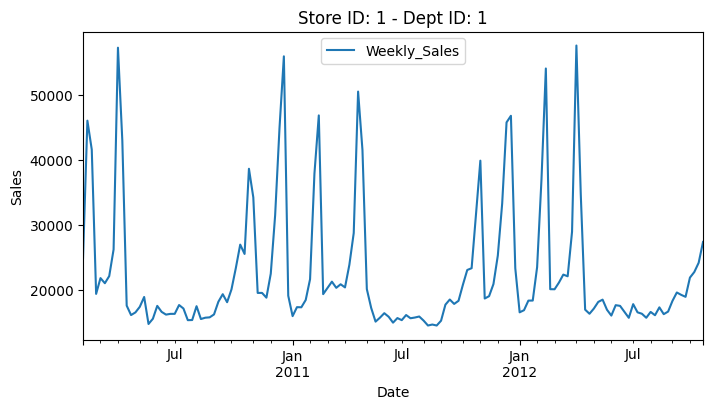

In [8]:
from src.plots import plot_sales

plot_sales(df_corrected, 1, 1)

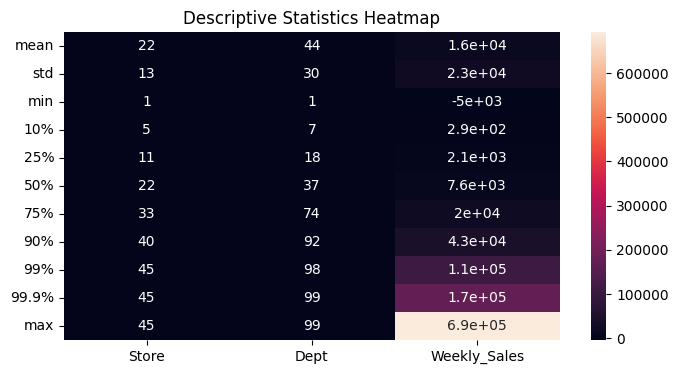

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
summary = (
    df_corrected[['Store', 'Dept', 'Weekly_Sales']].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.99, 0.999])
    .iloc[1:]
)
plt.figure(figsize=(8, 4)) 
sns.heatmap(summary, cmap='rocket', annot = True)
plt.title("Descriptive Statistics Heatmap")
plt.show()

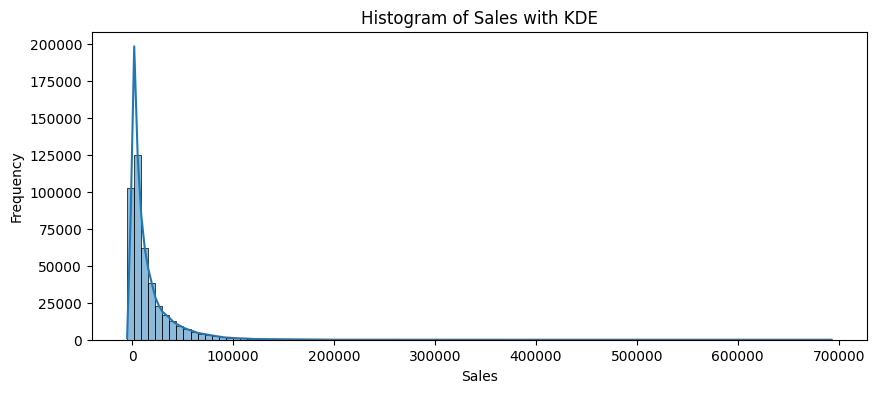

In [10]:
plt.figure(figsize=(10,4))
sns.histplot(df_corrected['Weekly_Sales'], bins=100, kde=True)
plt.title('Histogram of Sales with KDE')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

**as we can see, there are outliers in this dataset**

In [ ]:
# DO NOT CORRECT OUTLIER BECAUSE SALES OF DIFFERENT DEPT HAVE DIFFERENT RANGE

# from src.data_cleaning import corrected_outlier
# df_corrected = corrected_outlier(df_filled)
# df_corrected


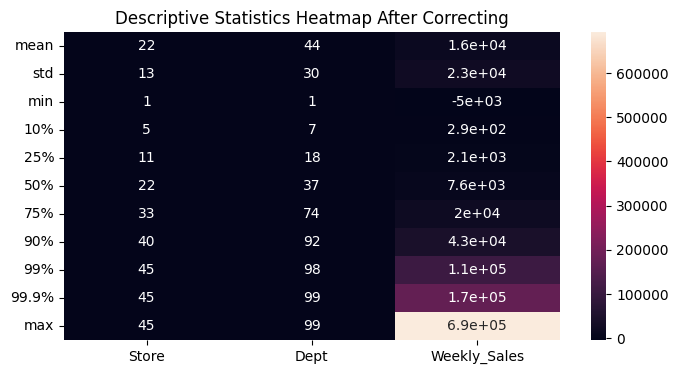

In [12]:
summary = (
    df_corrected[['Store', 'Dept', 'Weekly_Sales']].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.99, 0.999])
    .iloc[1:]
)
plt.figure(figsize=(8, 4)) 
sns.heatmap(summary, cmap='rocket', annot = True)
plt.title("Descriptive Statistics Heatmap After Correcting")
plt.show()

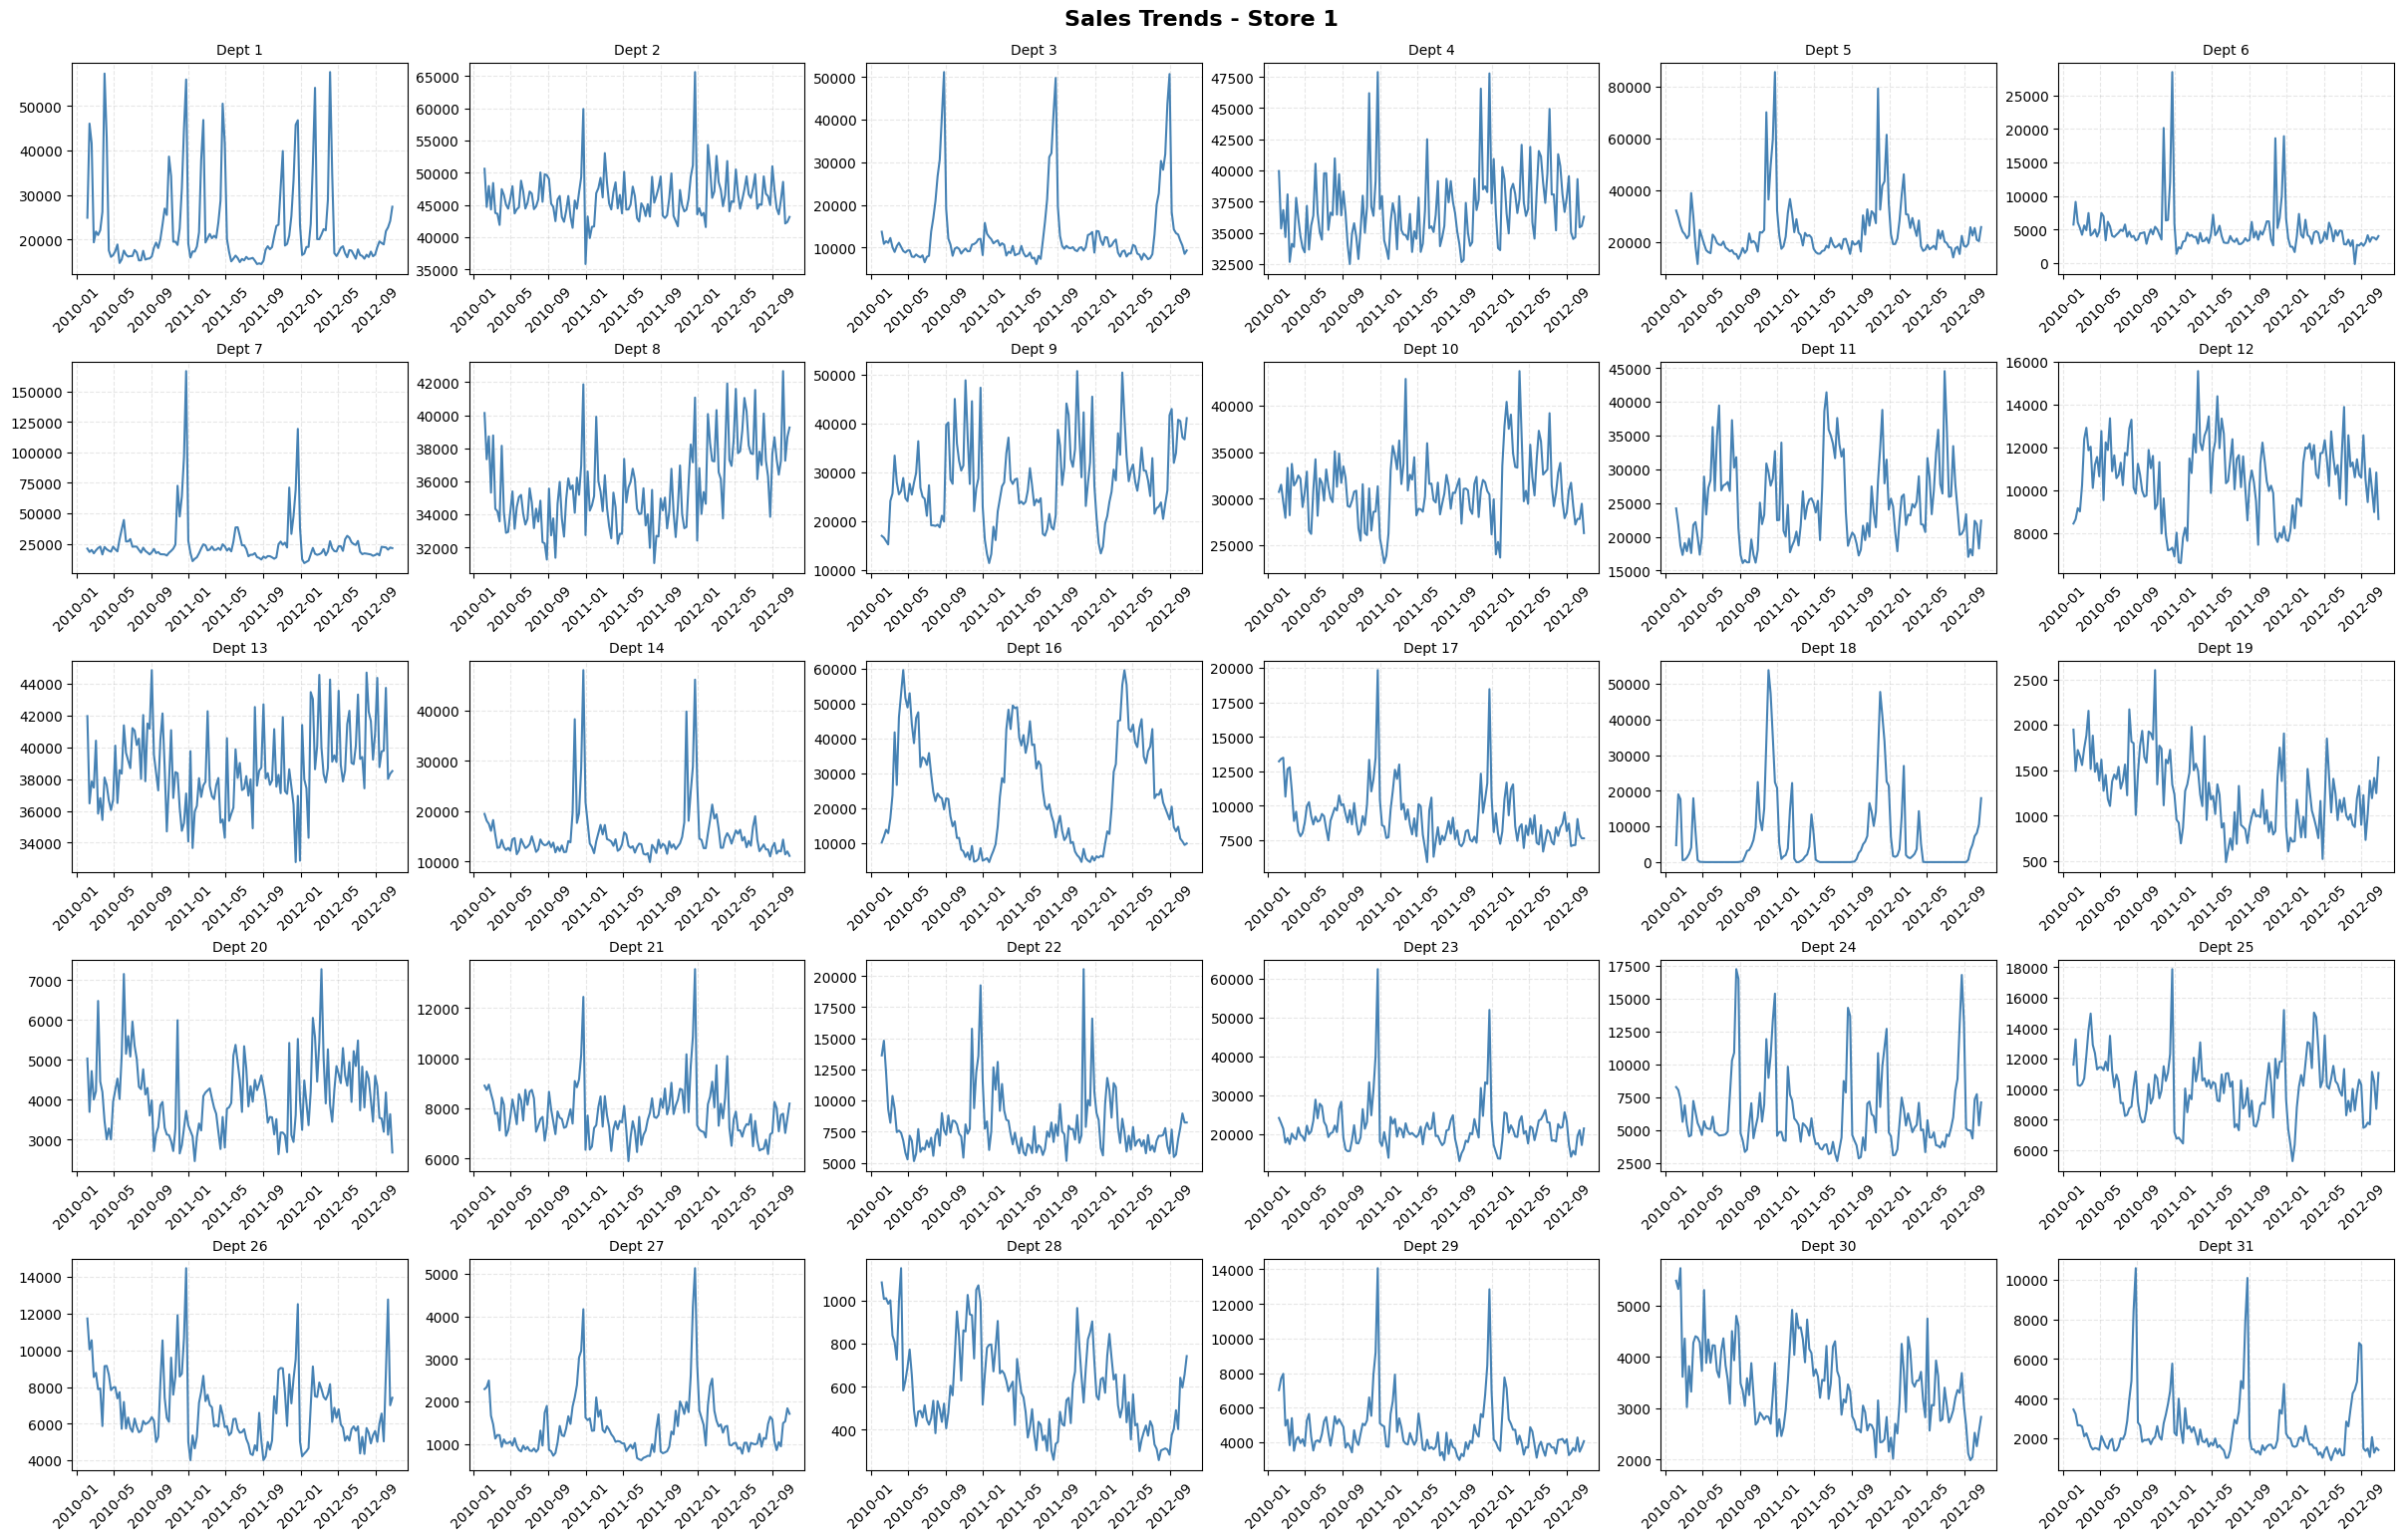

In [13]:
store_id = 1
df_store = df_corrected[df_corrected['Store'] == store_id]
dept_list = df_store['Dept'].unique()  


if len(dept_list) > 30:
    dept_list = dept_list[:30]  

n_rows, n_cols = 5, 6
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*4, n_rows*3), constrained_layout=True)
axes = axes.flatten()

for idx, dept in enumerate(dept_list):
    df_dept = df_store[df_store['Dept'] == dept].sort_values('Date')
    ax = axes[idx]
    ax.plot(df_dept['Date'], df_dept['Weekly_Sales'], color='steelblue', linewidth=1.5)
    ax.set_title(f'Dept {dept}', fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, linestyle='--', alpha=0.3)


for ax in axes[len(dept_list):]:
    ax.axis('off')

fig.suptitle(f'Sales Trends - Store {store_id}', fontsize=16, fontweight='bold', y=1.02)
plt.show()

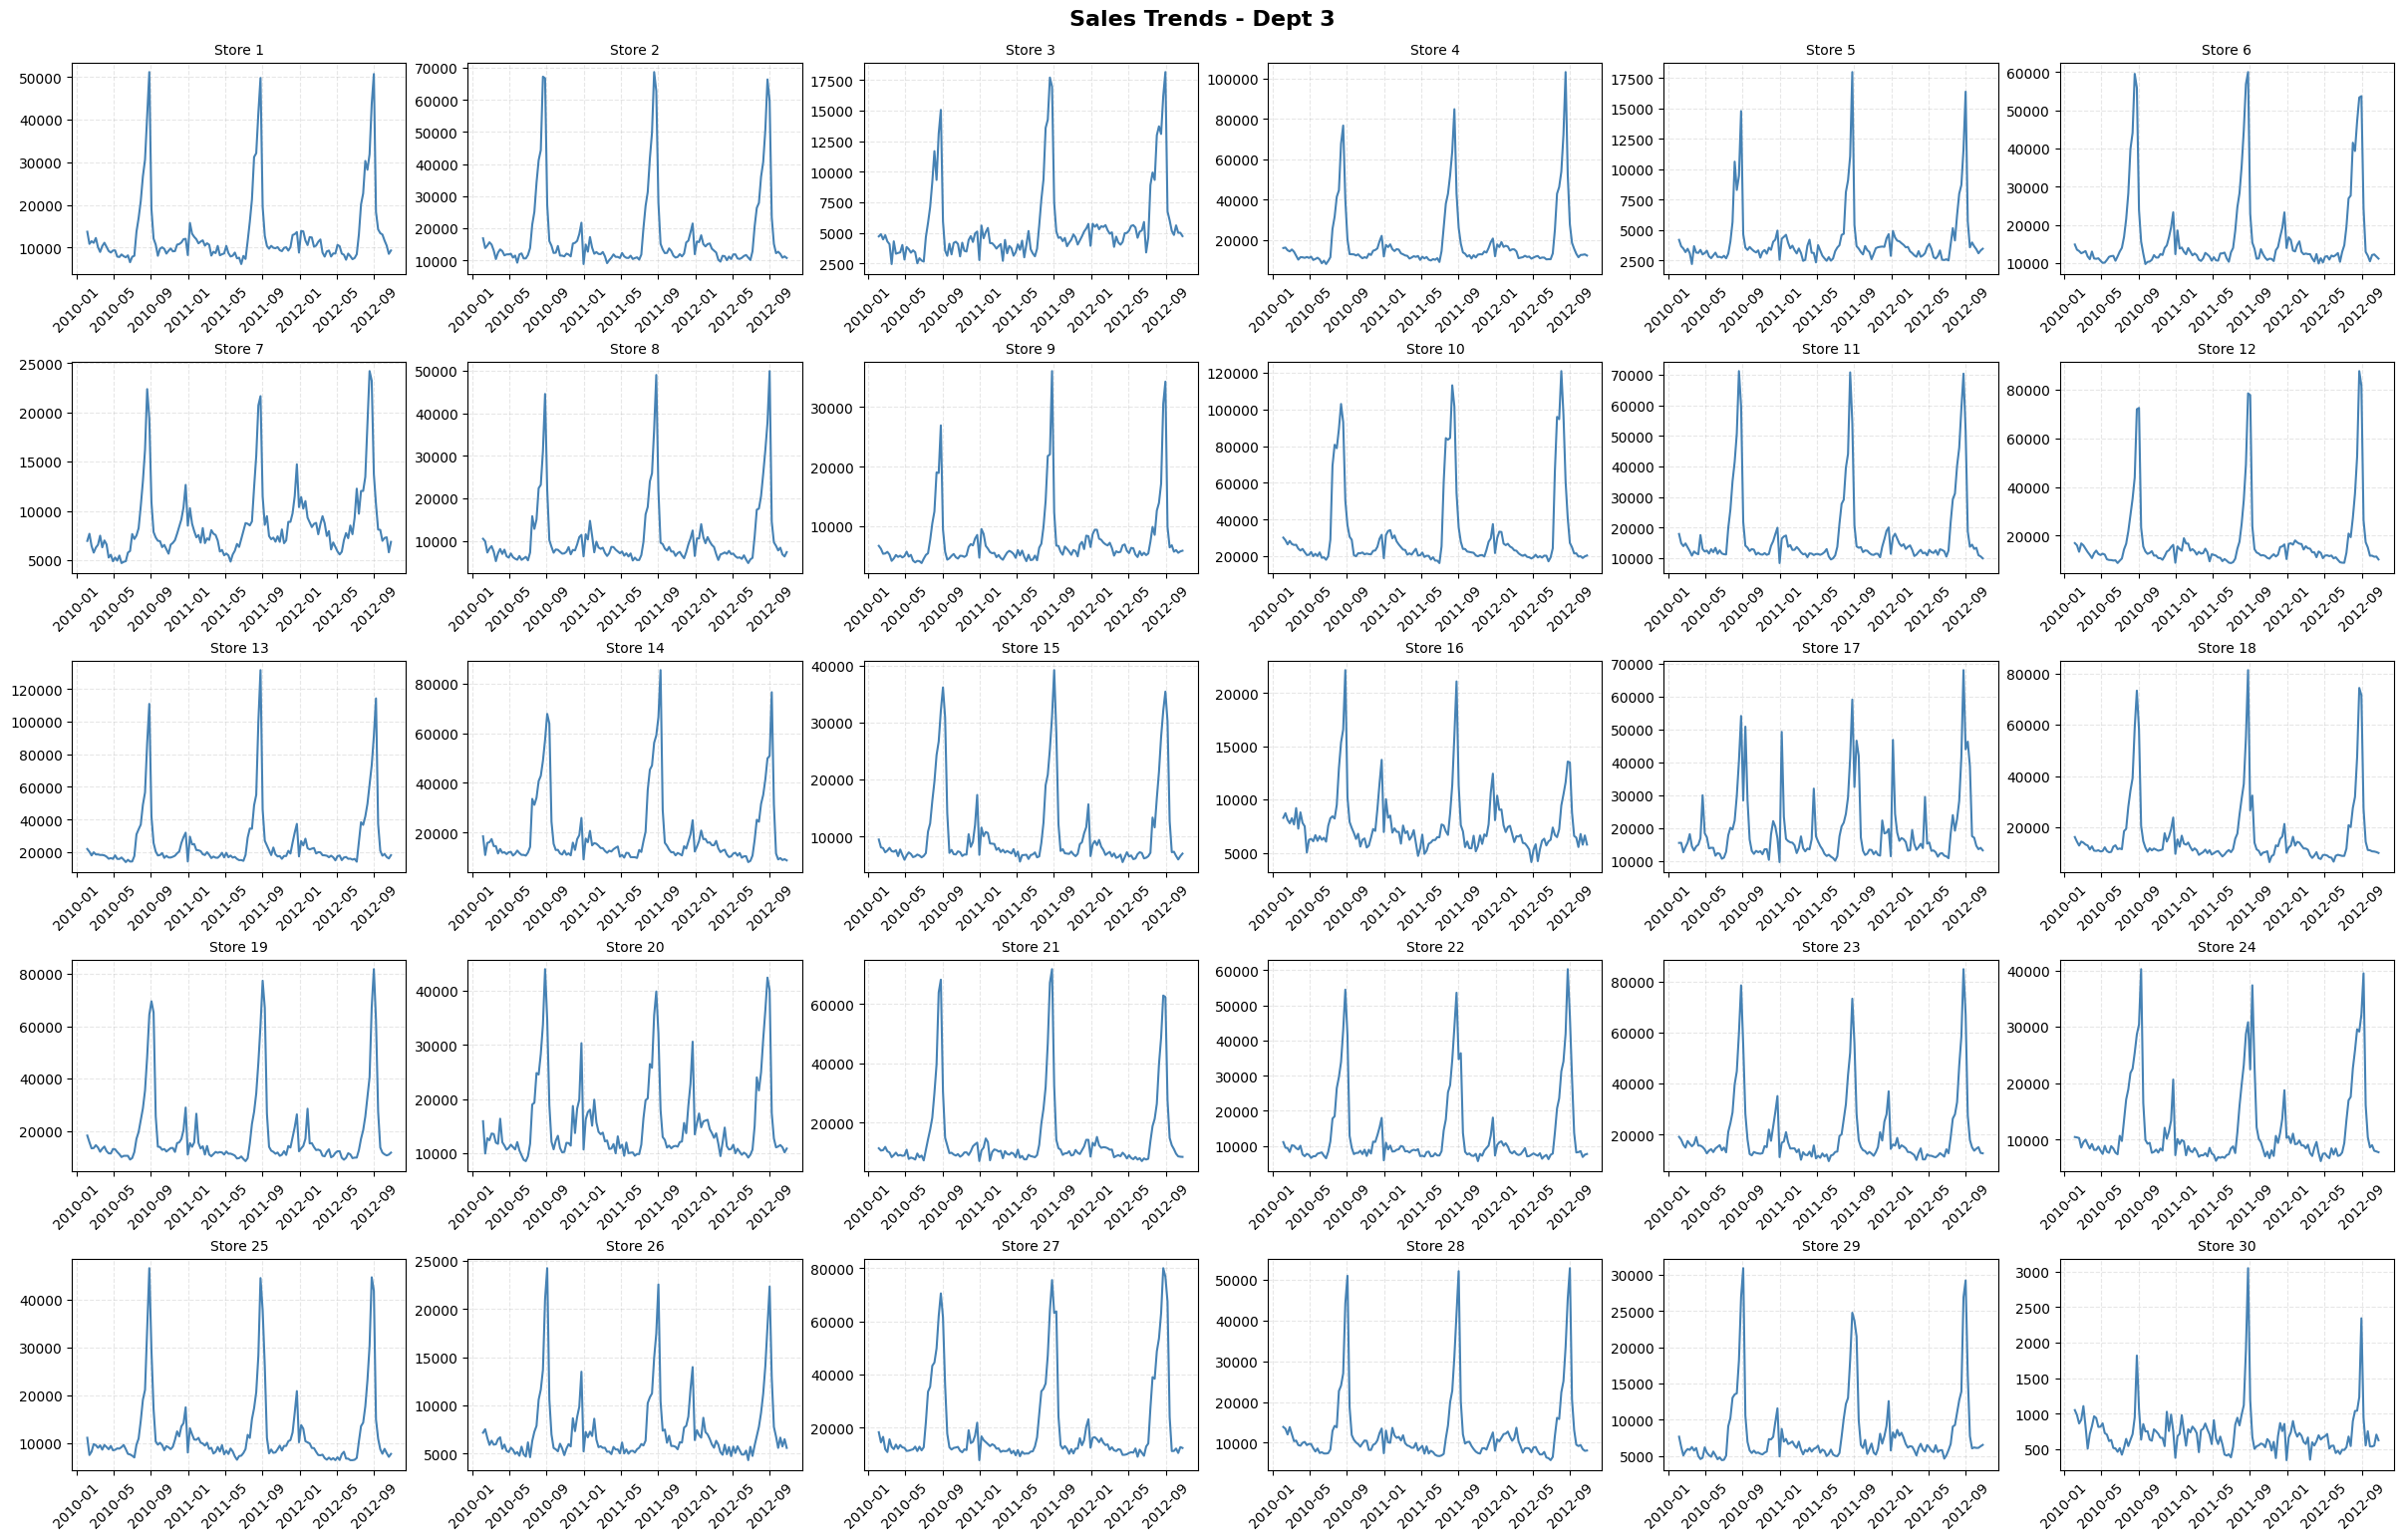

In [14]:
dept_id = 3 # THIS DEPT HAS AN UNIQUE, YEARLY PATTERN
df_dept = df_corrected[df_corrected['Dept'] == dept_id]
store_list = df_dept['Store'].unique()  


if len(store_list) > 30:
    store_list = store_list[:30]  

n_rows, n_cols = 5, 6
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*4, n_rows*3), constrained_layout=True)
axes = axes.flatten()

for idx, store in enumerate(store_list):
    df_plot = df_dept[df_dept['Store'] == store].sort_values('Date')
    ax = axes[idx]
    ax.plot(df_plot['Date'], df_plot['Weekly_Sales'], color='steelblue', linewidth=1.5)
    ax.set_title(f'Store {store}', fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, linestyle='--', alpha=0.3)


for ax in axes[len(store_list):]:
    ax.axis('off')

fig.suptitle(f'Sales Trends - Dept {dept_id}', fontsize=16, fontweight='bold', y=1.02)
plt.show()

In [15]:
import os

# position
%cd /content/Walmart_sales_forecasting


os.makedirs("data/processed", exist_ok=True)


save_file = "data/processed/sales_data_preprocessed.csv"

# save file
df_corrected.to_csv(save_file, index=False)

/content/Walmart_sales_forecasting


In [16]:
%cd /content/Walmart_sales_forecasting/data/processed/
!ls


/content/Walmart_sales_forecasting/data/processed
sales_data_preprocessed.csv
